In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings
 
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict
from src.layers.classifiers import TokenClassifier, MixedClassifier
import h5py
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm

In [2]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

In [3]:

path = '/home/mdelafuente/'#sys.argv[2]

device = torch.device(f"cuda:2" if torch.cuda.is_available() else "cpu")

h5_file = h5py.File(
    f"{path}/ORIGINAL/elasticc_dataset_update.h5", "r"
)

abs_path = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/MLP_baseline_SOBEL001_0/'
path_args = glob.glob(f"{abs_path}*args*")[0]
print(path_args)
import yaml
with open(path_args, 'r') as file:
    args = yaml.safe_load(file)

/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/MLP_baseline_SOBEL001_0/args.yaml


In [4]:
df  = pd.read_csv('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/MLP_baseline_SOBEL001_0/metrics.csv')

In [5]:
df

,epoch,loss_train/lc,loss_train/total,loss_validation/lc,loss_validation/total,lr-AdamW,step,train/acc_epoch,train/acc_step,train/f1_epoch,train/f1_step,train/recall_epoch,train/recall_step,validation/acc,validation/f1,validation/recall
0,NaN,NaN,NaN,NaN,NaN,0.0005,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,2.732677,2.732677,NaN,NaN,NaN,9,NaN,0.160156,NaN,0.147979,NaN,0.176872,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,0.0005,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,2.631037,2.631037,NaN,NaN,NaN,19,NaN,0.125000,NaN,0.122799,NaN,0.131941,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,0.0005,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,3.0,1.361143,1.361143,NaN,NaN,NaN,1259,NaN,0.523438,NaN,0.499673,NaN,0.511817,NaN,NaN,NaN
258,3.0,NaN,NaN,1.362109,1.362109,NaN,1263,NaN,NaN,NaN,NaN,NaN,NaN,0.542557,0.386791,0.421115
259,3.0,NaN,NaN,NaN,NaN,NaN,1263,0.537782,NaN,0.527338,NaN,0.538111,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,0.0005,1269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['epoch', 'loss_train/lc', 'loss_train/total', 'loss_validation/lc',
       'loss_validation/total', 'lr-AdamW', 'step', 'train/acc_epoch',
       'train/acc_step', 'train/f1_epoch', 'train/f1_step',
       'train/recall_epoch', 'train/recall_step', 'validation/acc',
       'validation/f1', 'validation/recall'],
      dtype='object')

In [7]:
def plot_umap(ax, umap_result, numeric_labels, num_classes, title):
    colors = ['#43aa8b', '#4d908e', '#ca5cdd', '#277da1','#f9c74f',
              '#90be6d','#f8961e', '#f94144', '#f9844a', '#90be6d', 
              '#f3722c','#277da1', '#43aa8b', '#577590', '#4d908e', 
              '#f9c74f','#90be6d', '#f94144', '#f3722c', '#f8961e', 
              '#f9844a', '#4d908e', '#ca5cdd']
    dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
    for i in range(num_classes):
        class_indices = numeric_labels == i
        markers = ['o', '^', '<', 'D', 'p',
                   'o', '^', '<', 'D', 'p', 
                   'o', '^', '<', 'D',
                   'o', '^', '<', 'D',
                   'o', '^', '<', 'D', 'p']
        ax.scatter(x=umap_result[class_indices, 0], y=umap_result[class_indices, 1],s=10, marker=markers[i],label=list(dict.keys())[i], color=colors[i],alpha = 0.75 )
        

    ax.set_facecolor('black')
    
    ax.set_title(title)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    
    plt.legend()

In [8]:
seed = 0
from src.data.modules.LitData  import LitData
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 1

pl_datal = LitData(**args['general'])
dataloader = pl_datal.val_dataloader() 
    

using set validation total of idx : 40698 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


In [9]:
target = None
preds_out = None
 
count = 0

from scipy import ndimage, datasets 

sobel_h_list = []
sobel_v_list = []
magnitude_list = []

for b1 in tqdm(dataloader):
    #b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
    t = b1['labels']
   # del b1['labels']
    
        
    for i in range(b1['data'].size(0)):
        signal = b1['data'][i,:,:].detach().cpu().numpy()
        
        sobel_h = ndimage.sobel(signal, 0) * (signal!=0) 
        if sobel_h.max() >1:
            sobel_h = sobel_h/sobel_h.max()
        sobel_h_list.append(sobel_h)
        
        sobel_v = ndimage.sobel(signal, 1) * (signal!=0)   # vertical gradient
        if sobel_v.max() >1:
            sobel_v = sobel_v/sobel_v.max()
        sobel_v_list.append(sobel_v)
        
        magnitude = np.sqrt(sobel_h**2 + sobel_v**2)  
        magnitude = (magnitude* (signal!=0))
        
        if magnitude.max() >1:
            magnitude = magnitude/magnitude.max()
        magnitude_list.append(magnitude)
 
    target = (
        np.concatenate([target, t.cpu().detach().numpy()])
        if target is not None
        else t.cpu().numpy()
    )
    if count > 200:
        break
    count +=1

  0%|          | 201/40698 [00:01<04:13, 159.96it/s]


In [10]:

from scipy import ndimage, datasets 
n = 0 # np.random.randint(0,32)
signal = b1['data'][n,:,:].detach().cpu().numpy()
signal_mask = b1['mask'][n,:,:].detach().cpu().numpy()

sobel_h = ndimage.sobel(signal, 0) * (signal!=0) # horizontal gradient
sobel_v = ndimage.sobel(signal, 1)  * (signal!=0)  # vertical gradient
print(sobel_h.shape) 



(200, 2)


In [24]:
from torchvision.transforms import Compose
import seaborn as sns
from src.augmentations import LightCurveTransform as LC
transform = Compose([LC.RandomSobelFilterMask(filter_type = 'horizontal',keep = 'below',threshold_range=(0.1,0.101))])

  0%|          | 0/40698 [00:00<?, ?it/s]

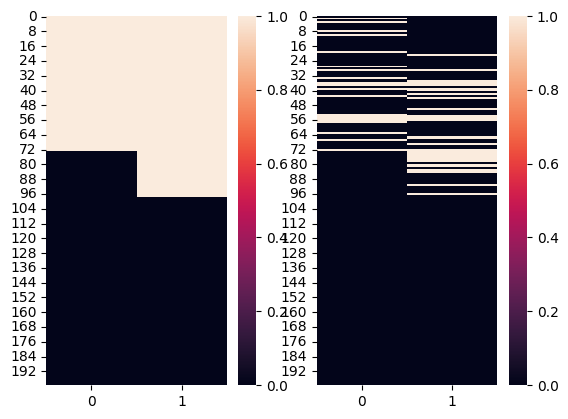

  0%|          | 1/40698 [00:00<7:38:11,  1.48it/s]

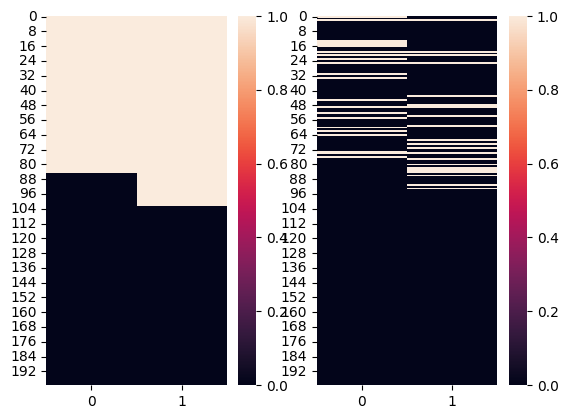

  0%|          | 2/40698 [00:01<5:35:49,  2.02it/s]

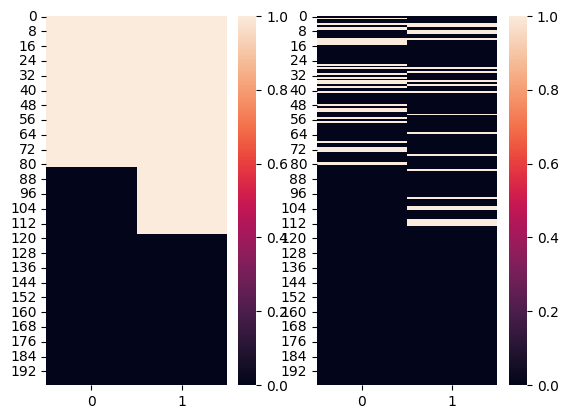

  0%|          | 3/40698 [00:01<4:53:14,  2.31it/s]

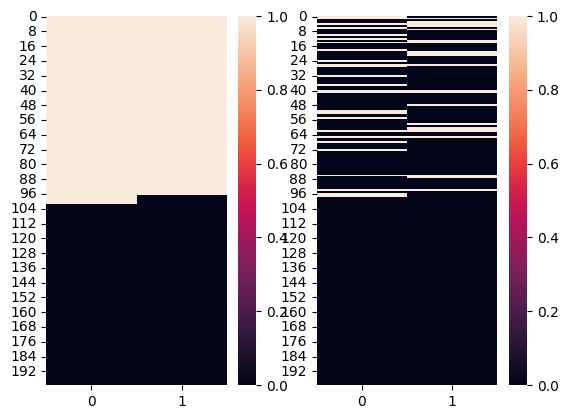

  0%|          | 4/40698 [00:01<4:33:00,  2.48it/s]

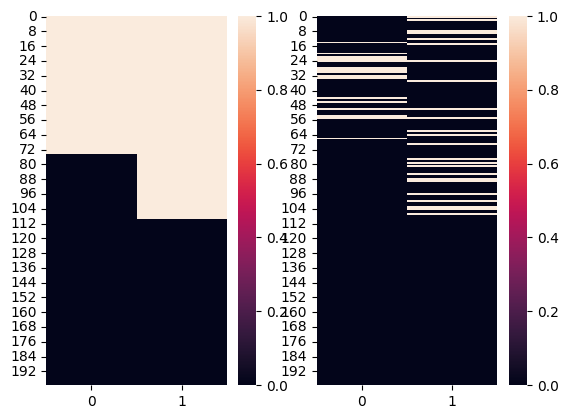

  0%|          | 5/40698 [00:02<4:23:20,  2.58it/s]

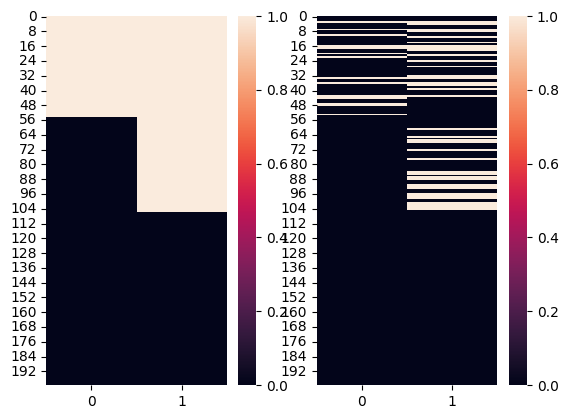

  0%|          | 6/40698 [00:02<4:15:20,  2.66it/s]

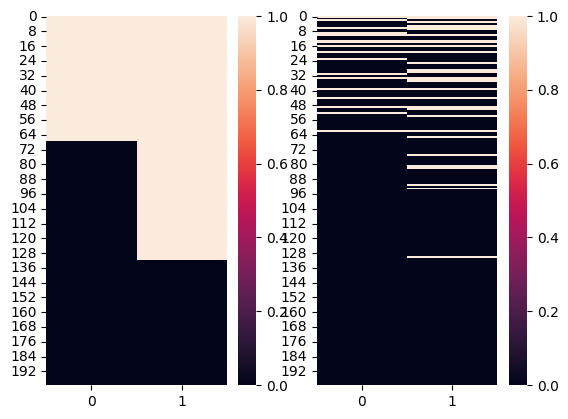

  0%|          | 7/40698 [00:02<4:18:51,  2.62it/s]

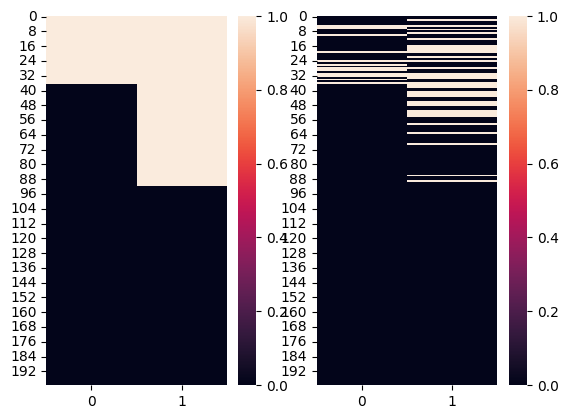

  0%|          | 8/40698 [00:03<5:31:17,  2.05it/s]

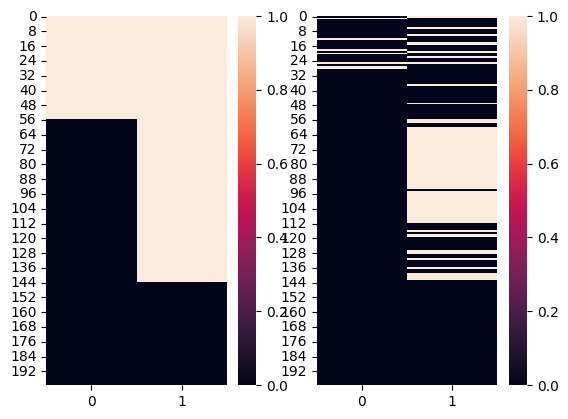

  0%|          | 9/40698 [00:03<5:05:15,  2.22it/s]

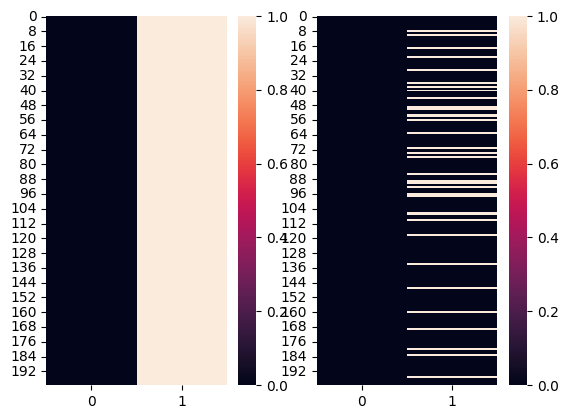

  0%|          | 10/40698 [00:04<4:45:54,  2.37it/s]

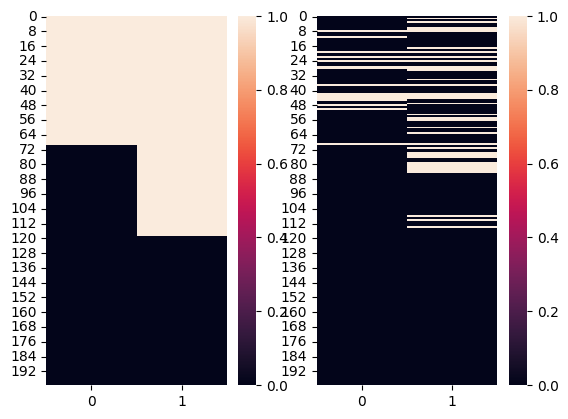

  0%|          | 11/40698 [00:04<4:29:28,  2.52it/s]

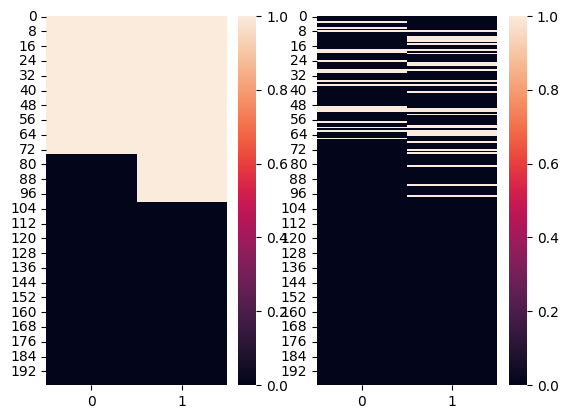

  0%|          | 11/40698 [00:05<5:13:21,  2.16it/s]


In [25]:
target = None
preds_out = None
 
count = 0

from scipy import ndimage, datasets 
from copy import deepcopy
sobel_h_list = []
sobel_v_list = []
magnitude_list = []

for b1 in tqdm(dataloader):
    #b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
    #print(b1['data'].squeeze(0).shape)
    for key,value in b1.items():
        b1[key] = value.squeeze(0)
     
    t = b1['labels']
    item = b1
    copied = deepcopy(item)
    test = transform(copied)
    fig,ax = plt.subplots(1,2)
    sns.heatmap(item['mask'],ax = ax[0])
    sns.heatmap(test['mask'],ax = ax[1])
    plt.show()
    if count > 10:
        break
    count +=1
    
 

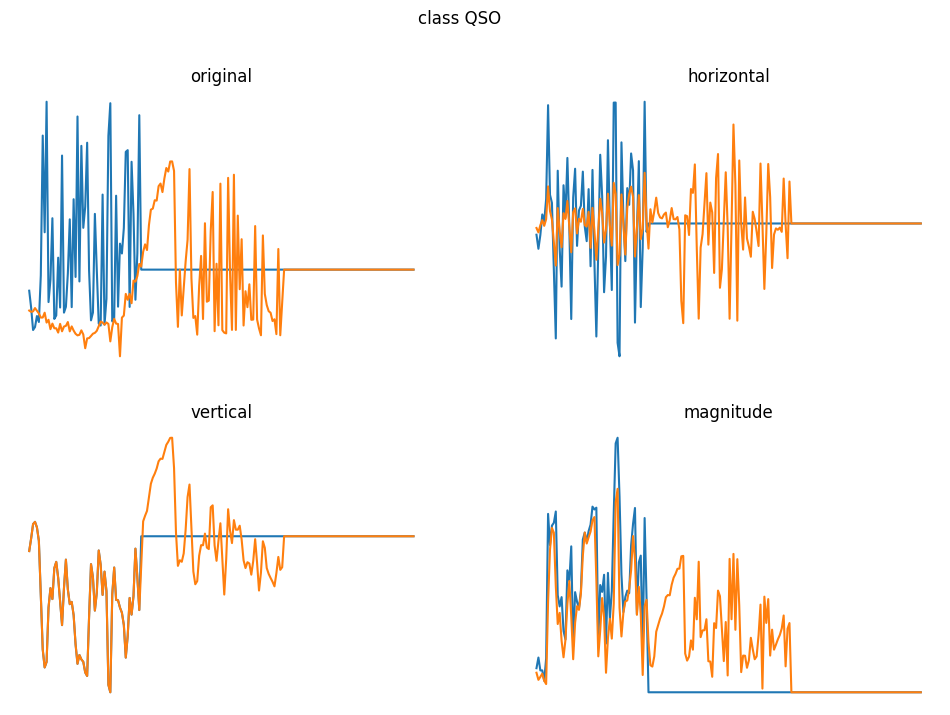

<Axes: >

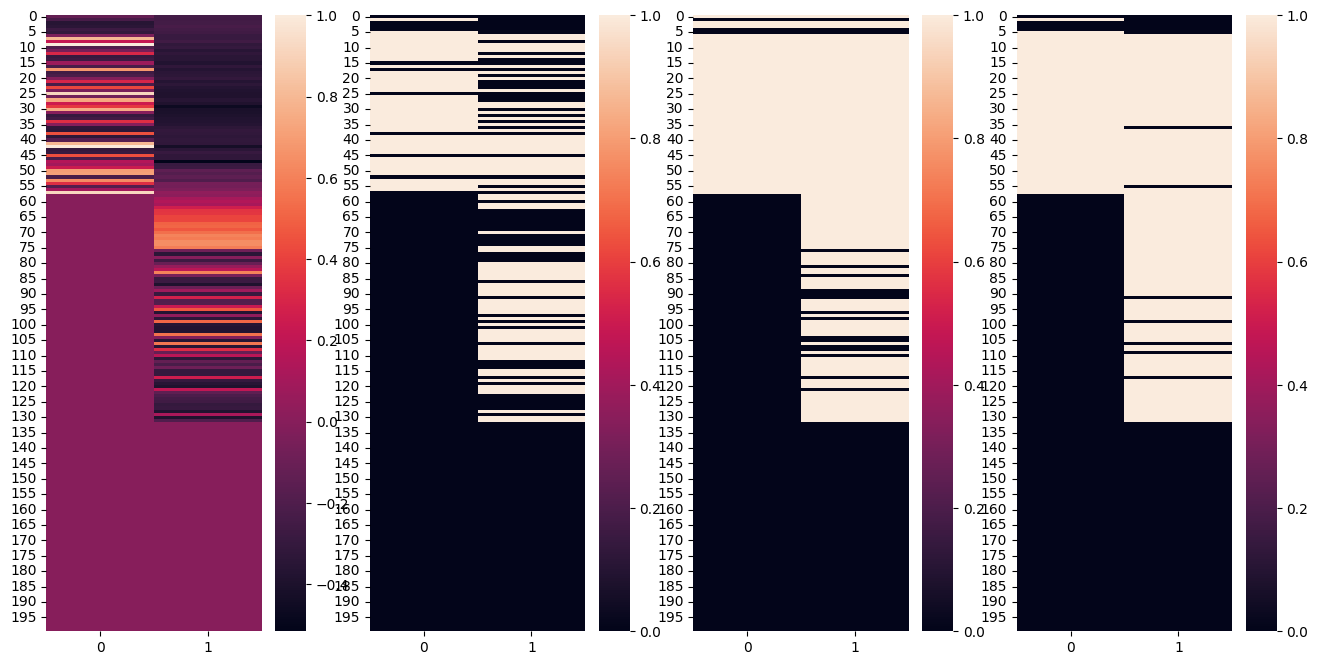

In [13]:
import seaborn as sns
magnitude = np.sqrt(sobel_h**2 + sobel_v**2)  * (signal!=0) 
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.gray()  # show the filtered result in grayscale
axs[0, 0].plot(signal)
axs[0, 1].plot(sobel_h)
axs[1, 0].plot(sobel_v)
axs[1, 1].plot(magnitude)

titles = ["original", "horizontal", "vertical", "magnitude"]
for i, ax in enumerate(axs.ravel()):
    ax.set_title(titles[i])
    ax.axis("off")
plt.suptitle(f'class {list(dict.keys())[b1['labels'][n].int()]}')
plt.show()

fig,ax = plt.subplots(1,4,figsize = (16,8))
sns.heatmap(signal/signal.max() * (signal !=0),ax = ax[0])
sns.heatmap((abs(sobel_h/sobel_h.max()* (signal !=0))>1e-1)& signal_mask,ax = ax[1])
sns.heatmap((abs(sobel_v/sobel_v.max()* (signal !=0))>1e-1) & signal_mask,ax = ax[2])
sns.heatmap((((magnitude/magnitude.max()* (signal !=0))> 1e-1) & signal_mask),ax = ax[3])


In [14]:
sobel_h_list = torch.tensor(sobel_h_list)
sobel_v_list = torch.tensor(sobel_v_list)
magnitude_list = torch.tensor(magnitude_list)

In [15]:
magnitude_list.shape

torch.Size([40698, 200, 2])

In [16]:
sobel_h_list.shape, target.shape,magnitude_list[:,:,0].shape

(torch.Size([40698, 200, 2]), (40698,), torch.Size([40698, 200]))

In [17]:
df_target = pd.DataFrame({'target': target.astype(int)})
class_indexes = pd.DataFrame({'class':range(0,22),'indexes': [df_target[df_target['target'] == i].index.to_list()  for i in range(0,22)]})
class_indexes

,class,indexes
0,0,"[57, 58, 59, 60, 61, 62, 63, 64, 71, 72, 73, 7..."
1,1,"[144, 145, 146, 147, 148, 149, 150, 151, 152, ..."
2,2,"[13, 14, 15, 16, 17, 18, 19, 128, 129, 130, 13..."
3,3,"[106, 107, 108, 109, 110, 111, 112, 113, 308, ..."
4,4,"[65, 66, 67, 68, 69, 70, 452, 453, 454, 455, 4..."
5,5,"[239, 240, 241, 242, 243, 244, 245, 246, 247, ..."
6,6,"[8, 9, 10, 11, 12, 78, 79, 80, 81, 82, 83, 84,..."
7,7,"[51, 833, 834, 835, 1271, 1272, 1273, 1274, 13..."
8,8,"[47, 48, 49, 50, 52, 53, 54, 55, 56, 91, 92, 9..."
9,9,"[353, 354, 355, 448, 462, 783, 784, 785, 786, ..."


In [18]:
for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
    #fig,ax = plt.subplots(1,1,figsize = (10,2))
    #mag = magnitude_list[class_indexes['indexes'].iloc[i]]
      
    #mag = mag.mean(dim = 0)
    #print(mag)
    
    #sns.lineplot(mag,ax = ax)
    #plt.show()
    
   

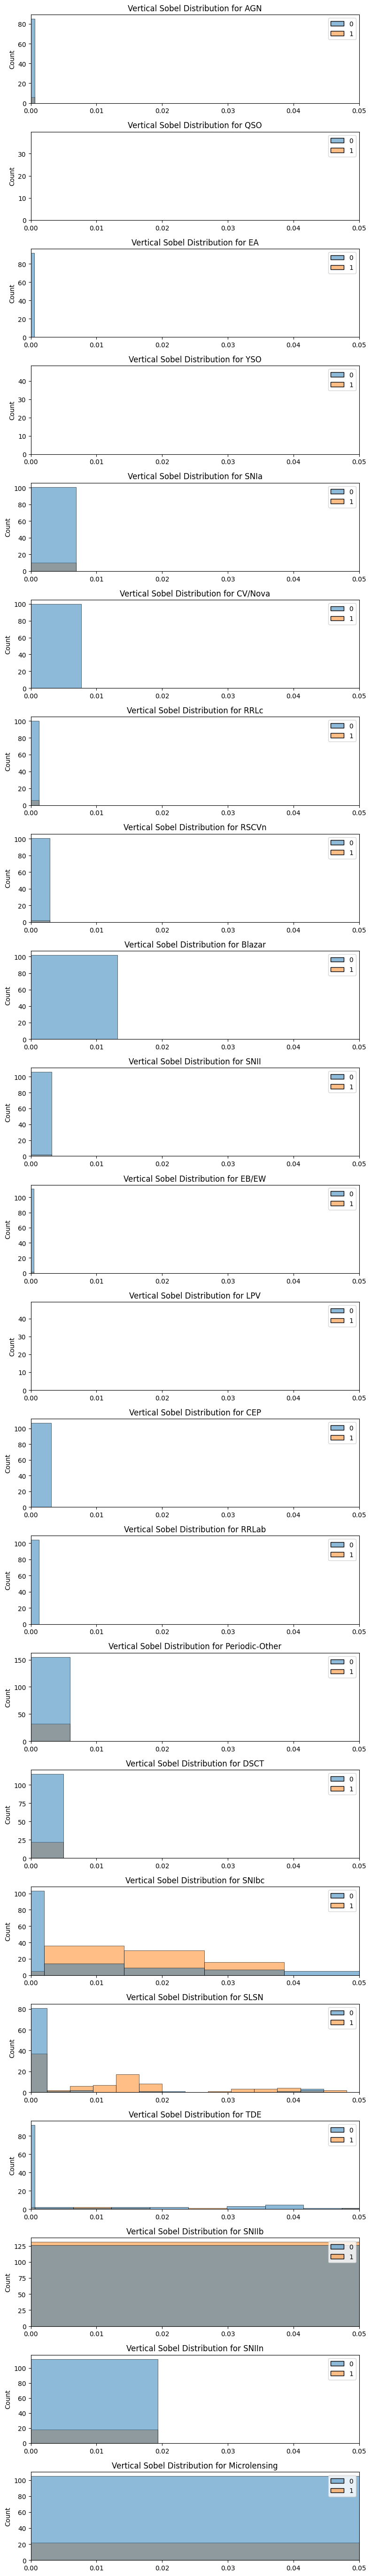

In [19]:

fig,ax = plt.subplots(22,1,figsize = (8,55))    

for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
    mag = sobel_v_list[class_indexes['indexes'].iloc[i]]
    mag = mag.mean(dim = 0)
     
    #print(mag.shape)#.mean(dim = 0)
    #sns.kdeplot(mag[:,0],ax = ax[0] )
    sns.histplot(mag,ax = ax[i], bins = 100,) 
    ax[i].set_title(f'Vertical Sobel Distribution for {list(dict.keys())[i]}', fontsize=12)
    
    ax[i].set_xlim(0,0.05)
    
plt.tight_layout()
plt.show()

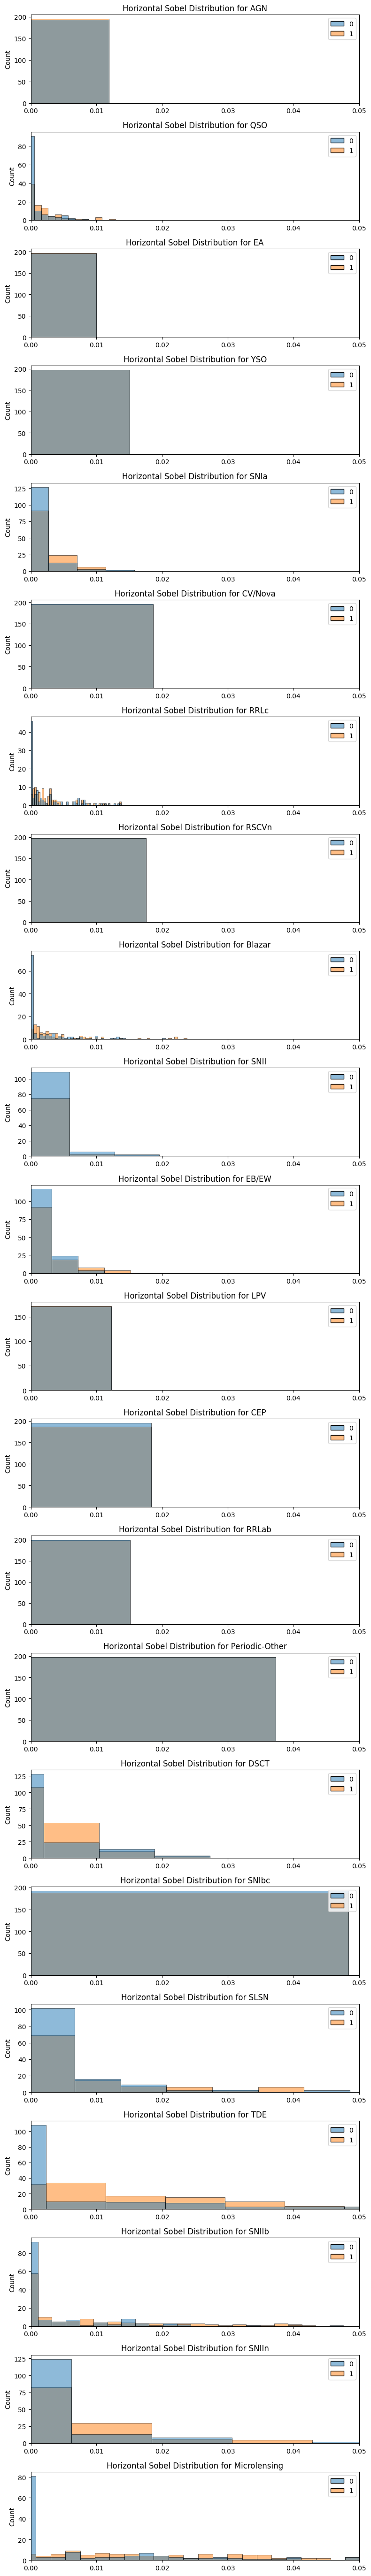

In [20]:

fig,ax = plt.subplots(22,1,figsize = (8,55))    

for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
    mag = sobel_h_list[class_indexes['indexes'].iloc[i]]
    mag = mag.mean(dim = 0)
     
    #print(mag.shape)#.mean(dim = 0)
    #sns.kdeplot(mag[:,0],ax = ax[0] )
    sns.histplot(mag,ax = ax[i], bins = 100,) 
    ax[i].set_title(f'Horizontal Sobel Distribution for {list(dict.keys())[i]}', fontsize=12)
   
    ax[i].set_xlim(0,0.05)
    
plt.tight_layout()
plt.show()

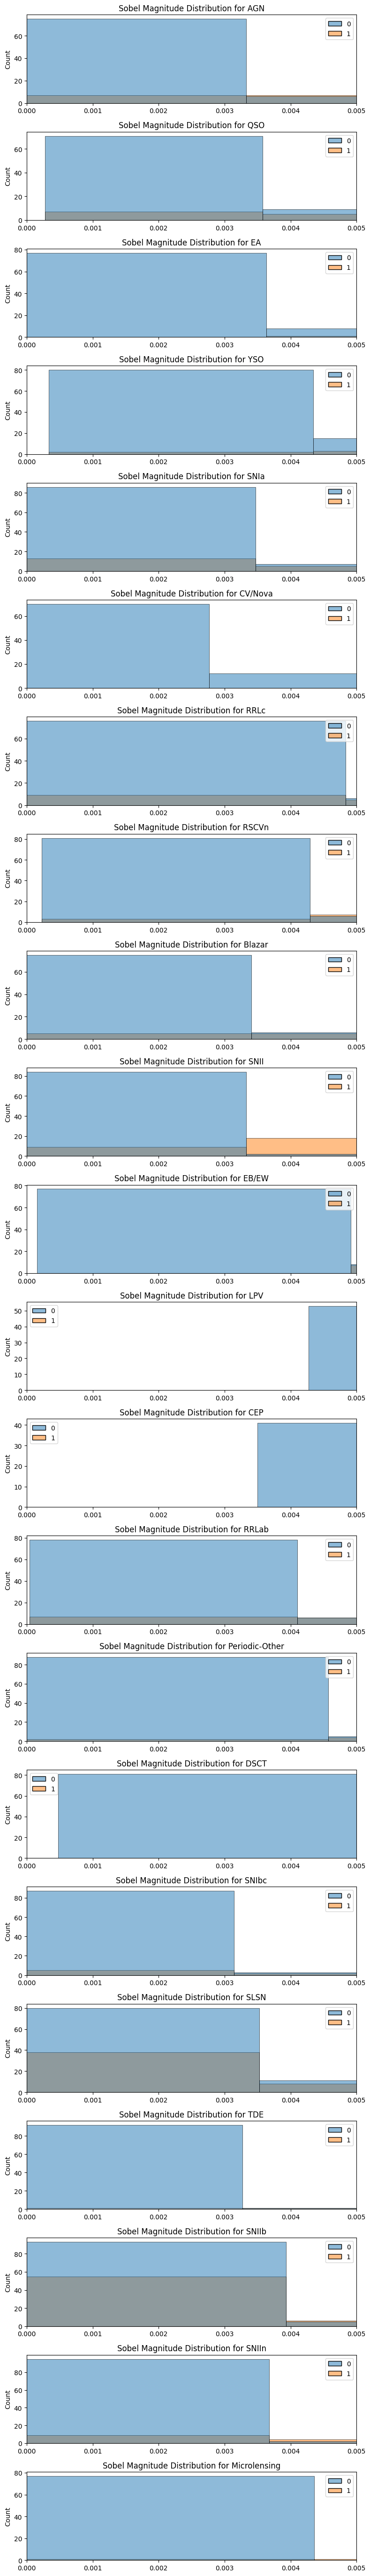

In [21]:
 
fig,ax = plt.subplots(22,1,figsize = (8,55))    

for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
    mag = magnitude_list[class_indexes['indexes'].iloc[i]]
    mag = mag.mean(dim = 0)
     
    #print(mag.shape)#.mean(dim = 0)
    #sns.kdeplot(mag[:,0],ax = ax[0] )
    sns.histplot(mag,ax = ax[i], bins = 100,) 
    ax[i].set_title(f'Sobel Magnitude Distribution for {list(dict.keys())[i]}', fontsize=12)
    #sns.kdeplot(mag[:,1],ax = ax[1])
    
    ax[i].set_xlim(0,0.005)
    
plt.tight_layout()
plt.show()  

In [22]:
asdfasf

NameError: name 'asdfasf' is not defined

asdfadsf

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, gaussian_filter
import seaborn as sns
rng = np.random.default_rng()
signal = b1['data'][12,:,0]
#signal = signal[signal.nonzero()]
signal = signal.detach().cpu().numpy()
y3 = gaussian_filter1d(signal, 0.02)
y6 = gaussian_filter1d(signal, 0.05)

y3 = (signal != 0)*y3
plt.plot(signal, 'k', label='original data',alpha = 0.5)
plt.plot(y3, '--', label='filtered, sigma=3', color = 'red')
plt.plot(y6, ':', label='filtered, sigma=1', color = 'blue')
plt.legend()

plt.show()

fig,ax = plt.subplots(1,2,figsize = (12,4))
rng = np.random.default_rng()
signal = b1['data'][12,:,:]
#signal = signal[signal.nonzero()]
signal = signal.detach().cpu().numpy() 
y3 = gaussian_filter(signal, 0.5) * (signal !=0)


sns.heatmap(signal/signal.max(),ax = ax[0],cmap = 'viridis')
sns.heatmap(y3/y3.max(),ax = ax[1],cmap = 'viridis')

plt.legend()

plt.show()





In [ ]:
from scipy import ndimage, datasets 

signal = b1['data'][1,:,:].detach().cpu().numpy()

sobel_h = ndimage.sobel(signal, 0)  # horizontal gradient
sobel_v = ndimage.sobel(signal, 1)  # vertical gradient
print(sobel_h.shape) 

magnitude = np.sqrt(sobel_h**2 + sobel_v**2)
#magnitude *= 255.0 / np.max(magnitude)  # normalization
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.gray()  # show the filtered result in grayscale
axs[0, 0].plot(signal)
axs[0, 1].plot(sobel_h)
axs[1, 0].plot(sobel_v)
axs[1, 1].plot(magnitude)
plt.legend(['signal','sobel_h','sobel_v','mag'])

titles = ["original", "horizontal", "vertical", "magnitude"]
for i, ax in enumerate(axs.ravel()):
    ax.set_title(titles[i])
    ax.axis("off")
plt.show()

fig,ax = plt.subplots(1,4,figsize = (16,8))
sns.heatmap(signal/signal.max() * (signal !=0),ax = ax[0])
sns.heatmap(sobel_h/sobel_h.max()* (signal !=0),ax = ax[1])
sns.heatmap(sobel_v/sobel_v.max()* (signal !=0),ax = ax[2])
sns.heatmap(magnitude/magnitude.max()* (signal !=0),ax = ax[3])

In [25]:
def big_group_plot_umap(ax, umap_result, numeric_labels, num_classes, title):
    colors = ['cyan','yellow','magenta']
    transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
    stochastic =  {
        "AGN": 0,
        "QSO": 1,
        "YSO": 3,
        "CV/Nova": 5,
        "Blazar": 8,
    }
    periodic =  {
        "EA": 2,
        "RRLc": 6,
        "RSCVn": 7,
        "EB/EW": 10,
        "LPV": 11,
        "CEP": 12,
        "RRLab": 13,
        "Periodic-Other": 14,
        "DSCT": 15,
    }
    
    for i in range(num_classes):
        class_indices = numeric_labels == i
        color = colors[0] if i in transient.values() else (colors[1] if i in stochastic.values() else colors[2])
        ax.scatter(x=umap_result[class_indices, 0], y=umap_result[class_indices, 1],s=7, color=color,alpha = 0.45) 
        

    ax.set_facecolor('black')
    
    ax.set_title(title)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    plt.legend(['transient', 'stochastic','periodic'])
    
    

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(25, 25))

big_group_plot_umap(axs, umap_result, target, 21,  'UMAP Visualization - concatenated embeddings ')